# Chapter 2: Mathematical Preliminaries

Consider a 2D function: f(**x**), **x**~(2) where we take the domain to be [0,10]:

$f(x) = sin(x_1)cos(x_2) + sin(0.5x_1)cos(0.5x_2)$

For each framework (NumPy, JAX, PyTorch):
1. Implement the function in a **vectorized** way, i.e. given a matrix **X**~(n,2) of *n* inputs, it should return a vector f(**X**) ~(n)

2. Implement another function to compute its gradient (hard-coded)

3. Write a basic gradient descent procedure and visualize the paths taken by the optimization process from multiple starting points

4. Try adding momentum term and visualizing the norm of the gradients, which should converge to zero as the algorithm moves towards a stationary point.

Step 3. is a good place to experiment with vmap for vectorizing a function.

# Section 1: NumPy

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np

# 1. Vectorized function
def function(X: np.ndarray) -> np.ndarray:
    """
    Vectorized function
    parameters
    ----------
    X : np.ndarray
        Input array of shape (n_samples, n_features)
    returns
    -------
    np.ndarray
        Output array of shape (n_samples,)
    """
    x_1 = X[:,0]
    x_2 = X[:,1]
    return np.sin(x_1)*np.cos(x_2) + np.sin(0.5*x_1)*np.cos(0.5*x_2)

X = np.array([[1, 2], [3, 4], [5, 6]], dtype=np.float64)
y = function(X)

print("Output:", y)
print("Shape of output:", y.shape)


Output: [-0.09114076 -0.50734658 -1.51321353]
Shape of output: (3,)


In [2]:

# 2. Hardcoded gradient
def gradient(X: np.ndarray) -> np.ndarray:
    """
    Hardcoded gradient function
    parameters
    ----------
    X : np.ndarray
        Input array of shape (n_samples, n_features)
    returns
    -------
    np.ndarray
        Gradient array of shape (n_samples, n_features)
    """
    x_1 = X[:,0]
    x_2 = X[:,1]
    grad_x1 = np.cos(x_1)*np.cos(x_2) + 0.5*np.cos(0.5*x_1)*np.cos(0.5*x_2)
    grad_x2 = -np.sin(x_1)*np.sin(x_2) - 0.5*np.sin(0.5*x_1)*np.sin(0.5*x_2)
    return np.column_stack((grad_x1, grad_x2))

print("\nGradient:", gradient(X))
print("Shape of gradient:", gradient(X).shape)



Gradient: [[ 0.01223485 -0.96685874]
 [ 0.63238375 -0.34670984]
 [ 0.66892709 -0.3101665 ]]
Shape of gradient: (3, 2)


In [3]:

# 3. Gradient descent function
def gradient_descent(X_init: np.ndarray, learning_rate: float = 0.01, n_iterations: int = 100):
    """
    Gradient descent function
    parameters
    ----------
    X : np.ndarray
        Input array of shape (n_samples, n_features)
    learning_rate : float
        Learning rate for the gradient descent
    n_iterations : int
        Number of iterations for the gradient descent
    returns
    -------
    np.ndarray
        Updated array after gradient descent
    """
    X = X_init.copy()
    trajectories =  [X.copy()]

    for _ in range(n_iterations):
        grad = gradient(X)
        X = X - learning_rate * grad
        trajectories.append(X.copy())

    return np.array(trajectories)

# Example usage
X0 = np.array([[1, 2], [3, 4], [5,6], [7,8], [9,10]], dtype=np.float64)
trajectories = gradient_descent(X0, learning_rate=0.05, n_iterations=1000)

#print("\nTrajectories after gradient descent:", trajectories)
print("\nTrajectories shape:", trajectories.shape)




Trajectories shape: (1001, 5, 2)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


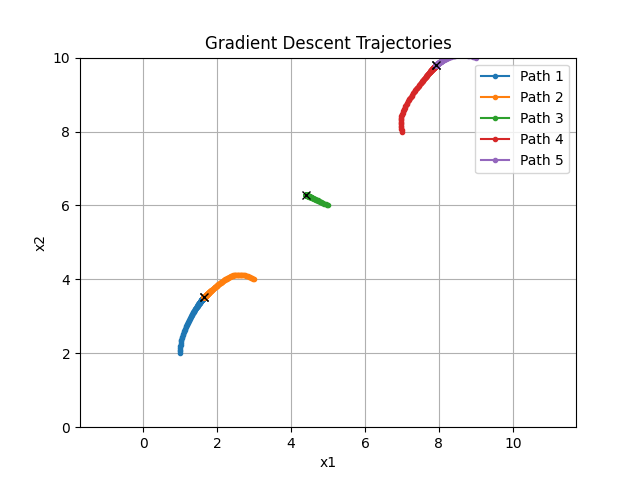

In [4]:

# 4a. 2D Visualization
def plot_2d_trajectories(trajectories):
    """
    Plots 2D gradient descent trajectories.

    Parameters
    ----------
    trajectories : np.ndarray
        Array of shape (steps, n_points, 2) containing optimization paths.
    """
    plt.figure()
    n_points = trajectories.shape[1]
    for i in range(n_points):
        path = trajectories[:, i, :]  # (steps, 2)
        plt.plot(path[:, 0], path[:, 1], marker='.', label=f'Path {i+1}')
        plt.plot(path[-1, 0], path[-1, 1], 'kx')  # final point

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Gradient Descent Trajectories')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.xlim(0, 10)
    plt.ylim(0, 10)
    plt.show()

# Example usage
plot_2d_trajectories(trajectories)

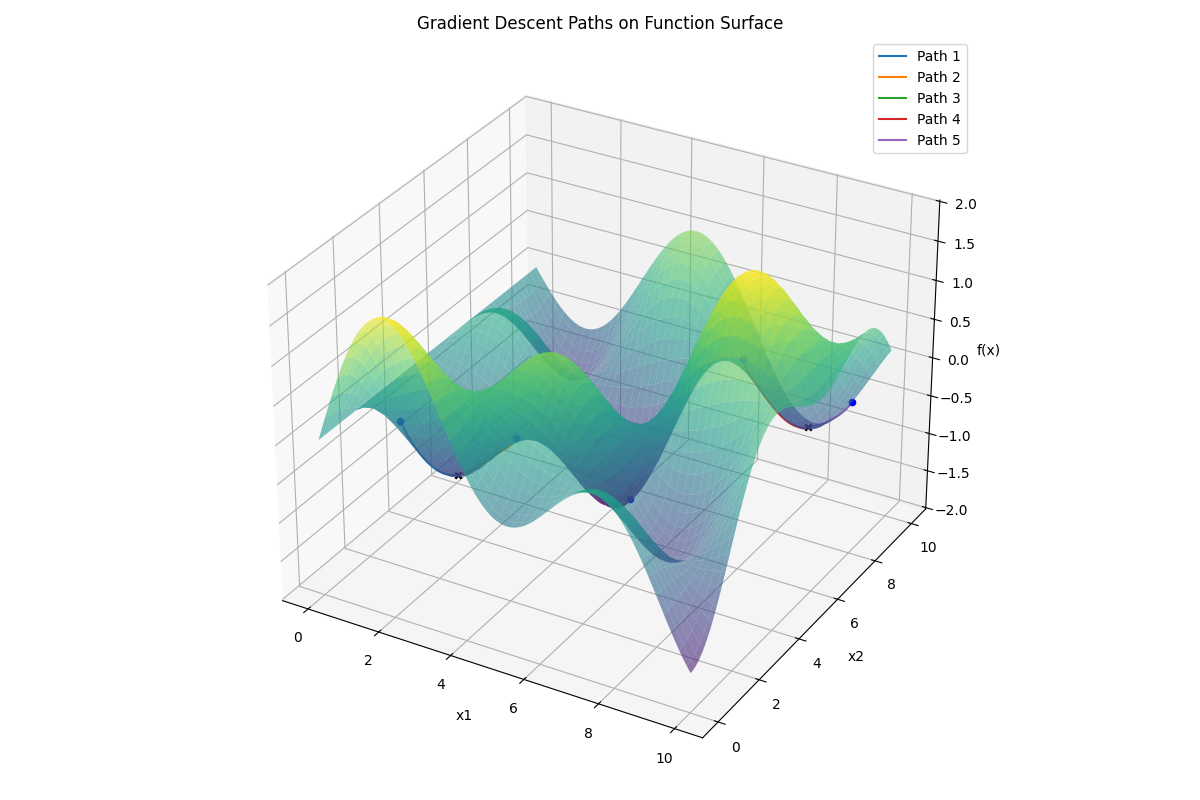

In [5]:
# 4b. 3D Visualization
def plot_3d_surface_and_paths(x1_range, x2_range, f, trajectories, X0):
    """
    Plots the 3D surface of f(x1, x2) and overlays gradient descent trajectories.

    Parameters
    ----------
    x1_range : np.ndarray
        1D array of x1 values.
    x2_range : np.ndarray
        1D array of x2 values.
    f : callable
        Function that takes (n, 2) array and returns (n,) array.
    trajectories : np.ndarray
        Array of shape (steps, n_points, 2) containing optimization paths.
    X0 : np.ndarray
        Initial points, shape (n_points, 2).
    """
    X1, X2 = np.meshgrid(x1_range, x2_range)
    X_flat = np.column_stack((X1.ravel(), X2.ravel()))
    Z = f(X_flat).reshape(X1.shape)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the surface
    ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.6, edgecolor='none')

    # Plot the trajectories
    for i in range(X0.shape[0]):
        path = trajectories[:, i, :]  # shape (steps, 2)
        z_path = f(path)
        ax.plot(path[:, 0], path[:, 1], z_path, '-', label=f'Path {i+1}')
        ax.scatter(path[0, 0], path[0, 1], z_path[0], c='blue', marker='o')  # start
        ax.scatter(path[-1, 0], path[-1, 1], z_path[-1], c='black', marker='x')  # end

    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('f(x)')
    ax.set_title('Gradient Descent Paths on Function Surface')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example usage
x1_range = np.linspace(0, 10, 100)
x2_range = np.linspace(0, 10, 100)
plot_3d_surface_and_paths(x1_range, x2_range, function, trajectories, X0)

In [6]:
# 5. Implementing Momentum
def gradient_descent_momentum(X_init: np.ndarray, learning_rate: float = 0.01, momentum:float = 0.3, n_iterations: int = 100):
    """
    Gradient descent function
    parameters
    ----------
    X : np.ndarray
        Input array of shape (n_samples, n_features)
    learning_rate : float
        Learning rate for the gradient descent
    momentum : float
        Momentum dampening parameter
    n_iterations : int
        Number of iterations for the gradient descent
    returns
    -------
    np.ndarray
        Updated array after gradient descent
    """
    X = X_init.copy()
    g = np.zeros_like(X)
    trajectories =  [X.copy()]

    for _ in range(n_iterations):
        grad = gradient(X)
        g = -learning_rate * grad + momentum * g
        X = X + g

        trajectories.append(X.copy())

    return np.array(trajectories)

# Example usage
X0 = np.array([[1, 2], [3, 4]], dtype=np.float64)
trajectories = gradient_descent_momentum(X0, learning_rate=0.05, momentum=0.3, n_iterations=1000)

#print("\nTrajectories after gradient descent:", trajectories)
print("\nTrajectories shape:", trajectories.shape)


Trajectories shape: (1001, 2, 2)


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


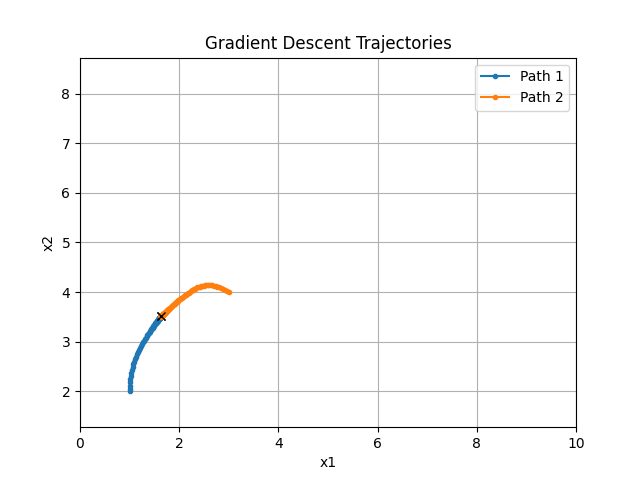

In [7]:
# 4a. 2D Visualization - Momentum
plot_2d_trajectories(trajectories)


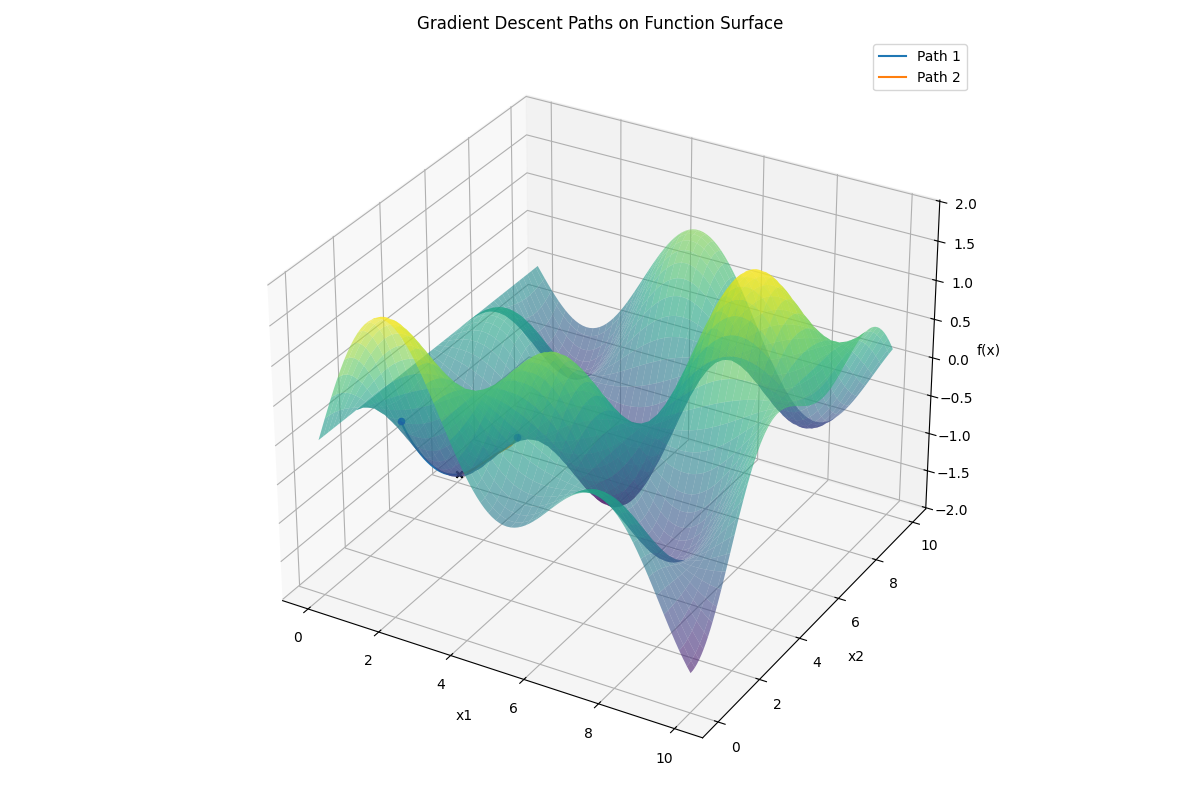

In [8]:
# 4b. 3D Visualization
plot_3d_surface_and_paths(x1_range, x2_range, function, trajectories, X0)


# Section 2: JAX

 v